# From Ion Channels to Memories

> **Central question**
>
> *A neuron can only spike. So where, exactly, is a **memory** — and on which
> timescale does it live?*

$$
\underbrace{\text{HH}}_{V,m,h,n}
\;\xrightarrow{\text{reduce}}
\underbrace{(V,n)}_{\text{2-variable}}
\;\longrightarrow\;
\underbrace{\text{spike events}}_{\{t_i\}}
\;\longrightarrow\;
\underbrace{\text{STDP}}_{\text{learn}}
\;\longrightarrow\;
\underbrace{\text{pattern completion}}_{\text{memory}}.
$$


*Run this cell first — it loads the simulation engine. All subsequent cells
depend on it.*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, fixed
import tutorial_models as M

plt.rcParams.update({
    "figure.figsize": (8, 4.5),
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 11, "figure.constrained_layout.use": True,
})
print("engine ready.")

engine ready.


## 1. Where does a memory live?

In the 1960s Eric Kandel took a sea slug, *Aplysia*, and touched its gill
repeatedly. The slug learned to **withdraw less** — a memory that lasted
minutes. Then he touched it and shocked its tail; the slug learned to withdraw
**more** — a memory that lasted *days*.

Kandel showed that **both memories were stored in the strength of synapses**.
Short-term memory = a synapse that temporarily changes transmitter release.
Long-term memory = a synapse that physically **rewires**.

> A memory is **not** a picture stored in a cell. It is a change in how cells
> talk to each other.

A **neuron** has a one-way signal flow:

$$
\text{dendrites (input)} \;\longrightarrow\; \text{soma (integrate)} \;\longrightarrow\;
\text{axon (spike)} \;\longrightarrow\; \text{synapse (to next neuron)}.
$$

- A **spike** is a brief all-or-nothing electrical pulse — the *currency* of the brain.
- Spikes are made by **ion channels** ($\text{Na}^+$ in, $\text{K}^+$ out).
- **Plasticity** = a synapse changing strength. Two kinds, two timescales:

| | **Short-term (STP)** | **Long-term (STDP / LTP)** |
|---|---|---|
| Timescale | ms – s | minutes – persistent |
| Changes the **weight**? | **No** | **Yes** |

## 2. The Hodgkin–Huxley model — where does the spike come from?

**Step 1:** A membrane is a capacitor: $C_m\frac{dV}{dt} = I_{\text{ext}} - I_{\text{Na}} - I_{\text{K}} - I_{\text{L}}$.

**Step 2:** Each ionic current = conductance $\times$ fraction-open $\times$ driving force:

$$
I_{\text{ion}} = \bar g_{\text{ion}} \cdot p_{\text{open}} \cdot (V - E_{\text{ion}}).
$$

**Step 3:** Voltage controls opening via gating variables $x \in [0,1]$:

$$
\frac{dx}{dt} = \frac{x_\infty(V) - x}{\tau_x(V)}.
$$

**Step 4 — assemble.** The four-variable model:

$$
C\frac{dV}{dt} = I_{\text{ext}}
- \bar g_{\text{Na}}\,m^3 h\,(V-E_{\text{Na}})
- \bar g_{\text{K}}\,n^4(V-E_{\text{K}})
- g_L(V-E_L).
$$

The spike **emerges** — it is not added by hand:

> **Fast positive feedback** (rise): $V\!\uparrow \Rightarrow m\!\uparrow \Rightarrow I_{\text{Na}}\!\uparrow \Rightarrow V\!\uparrow$
>
> **Slow negative feedback** (fall): $V\!\uparrow \Rightarrow n\!\uparrow, h\!\downarrow \Rightarrow$ $\text{Na}^+$ weakens, $\text{K}^+$ strengthens

*(The $n^4$ term predicted that the $\text{K}^+$ channel has four subunits — confirmed
structurally 40 years later. A model built from voltage-clamp curves predicted
the molecule.)*

*Run the HH model with a brief current pulse. Left: voltage. Right: the two
competing ionic currents. The gating variables $m, h, n$ are shown below.*

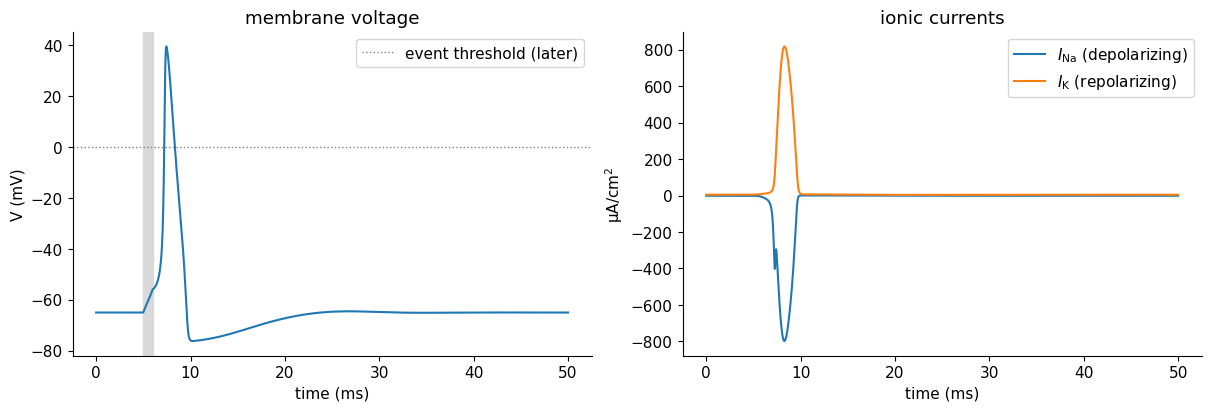

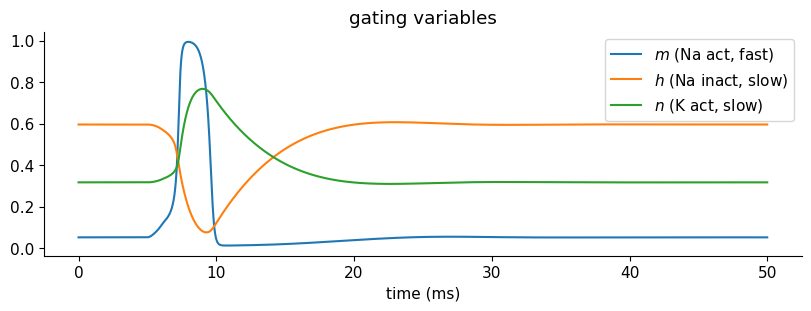

In [ ]:
I_AMP = 10.0
T_START, T_END = 5.0, 6.0

full = M.simulate_hh(I_amp=I_AMP, t_start=T_START, t_end=T_END)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(full["t"], full["V"], color="C0")
axs[0].axvspan(T_START, T_END, color="0.85")
axs[0].axhline(0.0, color="0.5", ls=":", lw=1, label="event threshold (later)")
axs[0].set_title("membrane voltage"); axs[0].set_xlabel("time (ms)")
axs[0].set_ylabel("V (mV)"); axs[0].legend()
axs[1].plot(full["t"], full["I_Na"], label=r"$I_{\mathrm{Na}}$ (depolarizing)")
axs[1].plot(full["t"], full["I_K"], label=r"$I_{\mathrm{K}}$ (repolarizing)")
axs[1].set_title("ionic currents"); axs[1].set_xlabel("time (ms)")
axs[1].set_ylabel(r"µA/cm$^2$"); axs[1].legend()
plt.show()

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(full["t"], full["m"], label=r"$m$ (Na act, fast)")
ax.plot(full["t"], full["h"], label=r"$h$ (Na inact, slow)")
ax.plot(full["t"], full["n"], label=r"$n$ (K act, slow)")
ax.set_title("gating variables"); ax.set_xlabel("time (ms)"); ax.legend()
plt.show()

---

> **Extension — Interactive HH — push the model around**  
> *Not covered in the one-hour lecture. Explore at home.*


Now that you have seen one spike, use the sliders to explore:
- `I_amp`: below ~6 µA/cm² the cell is silent; above it fires repetitively.
- `gK`: set to **0** and watch the spike fail to repolarize — the $\text{K}^+$
  channel (the tetramer!) is what brings the membrane back down.

In [ ]:
interact(M.explore_hh, I_amp=(0.0, 30.0, 0.5), gK=(0.0, 60.0, 1.0), t_end=fixed(30.0));

interactive(children=(FloatSlider(value=10.0, description='I_amp', max=30.0, step=0.5), FloatSlider(value=36.0…

## 3. Reduce HH until only a spike event remains

Multiscale modelling = choosing **what must survive** when the question moves
to a new scale. At every step: *what to preserve? what to discard?*

$$
(V,m,h,n) \;\longrightarrow\; (V,h,n) \;\longrightarrow\; (V,n) \;\longrightarrow\; \{t_i\}
$$

### 3.1 Reduction 1 — replace fast $m$ by $m_\infty(V)$

| gate | $\tau$ at rest |
|---|---:|
| $m$ | 0.24 ms |
| $h$ | 8.5 ms |
| $n$ | 5.5 ms |

$m$ is $\sim$20$\times$ faster $\Rightarrow$ it tracks voltage almost instantly:
$m(t) \approx m_\infty(V(t))$. **4 states → 3.**

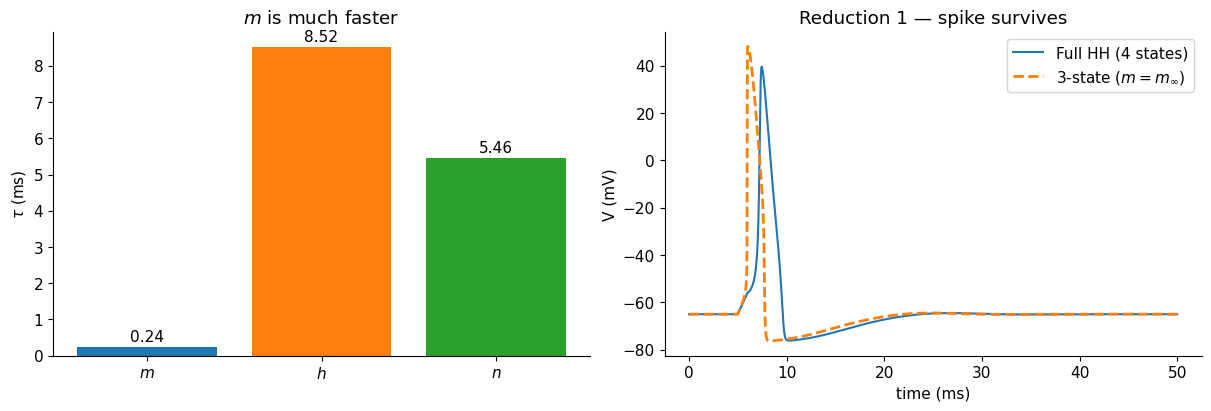

In [ ]:
V_REF = -65.0
gate_taus = [float(M.tau_m(V_REF)), float(M.tau_h(V_REF)), float(M.tau_n(V_REF))]
gate_names = [r"$m$", r"$h$", r"$n$"]

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].bar(gate_names, gate_taus, color=["C0", "C1", "C2"])
axs[0].set_ylabel(r"$\tau$ (ms)"); axs[0].set_title(r"$m$ is much faster")
for i, v in enumerate(gate_taus):
    axs[0].text(i, v + 0.15, f"{v:.2f}", ha="center")

three = M.simulate_hh_three_variable(I_amp=I_AMP, t_start=T_START, t_end=T_END)
axs[1].plot(full["t"], full["V"], label="Full HH (4 states)")
axs[1].plot(three["t"], three["V"], "--", lw=2, label=r"3-state ($m=m_\infty$)")
axs[1].set_title("Reduction 1 — spike survives"); axs[1].set_xlabel("time (ms)")
axs[1].set_ylabel("V (mV)"); axs[1].legend()
plt.show()

### 3.2 Reduction 2 — collapse $h$ and $n$ into one recovery variable

Both $h$ and $n$ pull the system back to rest. If they co-vary, we can fit
$h \approx a - b\,n$ from the HH trajectory. **3 states → 2.**

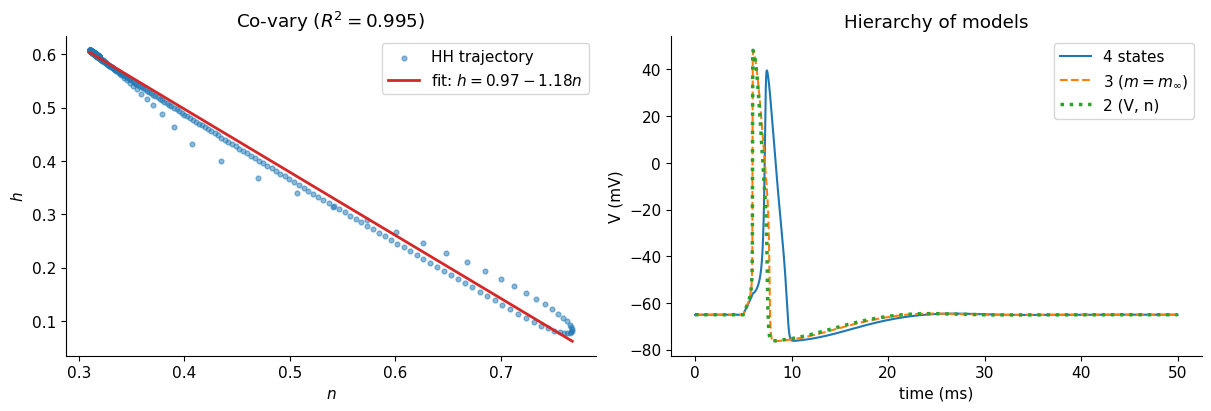

h ≈ 0.970 − 1.183·n   (R² = 0.995)


In [ ]:
a_fit, b_fit, r2 = M.fit_h_from_n(full["n"], full["h"])
n_line = np.linspace(full["n"].min(), full["n"].max(), 200)
two = M.simulate_hh_two_variable(I_amp=I_AMP, t_start=T_START, t_end=T_END,
                                  a_fit=a_fit, b_fit=b_fit)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].scatter(full["n"][::8], full["h"][::8], s=12, alpha=0.5, label="HH trajectory")
axs[0].plot(n_line, M.h_from_n(n_line, a_fit, b_fit), "C3", lw=2,
            label=rf"fit: $h={a_fit:.2f}-{b_fit:.2f}n$")
axs[0].set_xlabel(r"$n$"); axs[0].set_ylabel(r"$h$")
axs[0].set_title(rf"Co-vary ($R^2={r2:.3f}$)"); axs[0].legend()

axs[1].plot(full["t"], full["V"], label="4 states")
axs[1].plot(three["t"], three["V"], "--", label=r"3 ($m=m_\infty$)")
axs[1].plot(two["t"], two["V"], ":", lw=2.5, label="2 (V, n)")
axs[1].set_title("Hierarchy of models"); axs[1].set_xlabel("time (ms)")
axs[1].set_ylabel("V (mV)"); axs[1].legend()
plt.show()
print(f"h ≈ {a_fit:.3f} − {b_fit:.3f}·n   (R² = {r2:.3f})")

### 3.3 Reduction 3 — keep only the spike event time

When the next scale only needs "did a spike happen, and when?", we convert the
waveform to discrete events by threshold crossing. **2 states → event list.**

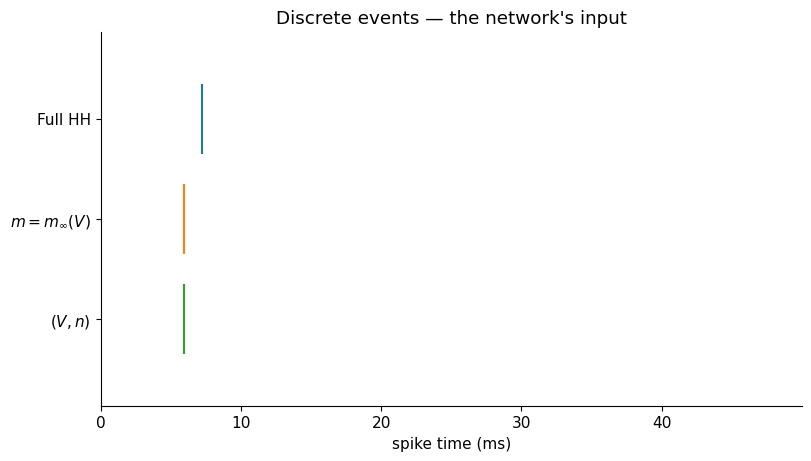

In [ ]:
EVENT_THRESHOLD = 0.0
spikes_full  = M.detect_spikes(full["t"],  full["V"],  EVENT_THRESHOLD)
spikes_three = M.detect_spikes(three["t"], three["V"], EVENT_THRESHOLD)
spikes_two   = M.detect_spikes(two["t"],   two["V"],   EVENT_THRESHOLD)

plt.figure()
plt.eventplot([spikes_full, spikes_three, spikes_two],
              lineoffsets=[3, 2, 1], linelengths=0.7, colors=["C0", "C1", "C2"])
plt.yticks([3, 2, 1], ["Full HH", r"$m=m_\infty(V)$", r"$(V,n)$"])
plt.xlabel("spike time (ms)"); plt.title("Discrete events — the network's input")
plt.xlim(0, full["t"][-1])
plt.show()

### 3.4 The single-neuron ladder

| Model | States | Preserves | Discards |
|---|:--:|---|---|
| Full HH | $V,m,h,n$ | ion mechanism, waveform | molecular structure |
| Fast-$m$ HH | $V,h,n$ | excitation + recovery | finite $m$ response |
| Two-variable | $V,n$ | fast excitation + slow recovery | independent $h$ |
| Events | $\{t_i\}$ | whether & when spikes occur | waveform, channels |

> Every rung preserves the one thing the rest of the brain listens to:
> the **spike time**.

---

> **Extension — Stress test — when does the reduction fail?**  
> *Not covered in the one-hour lecture. Explore at home.*


A brief pulse gives one event in all three models. Under **sustained**
stimulation, small differences in recovery dynamics accumulate and can change
the spike count. This is the **failure boundary** of the approximation.

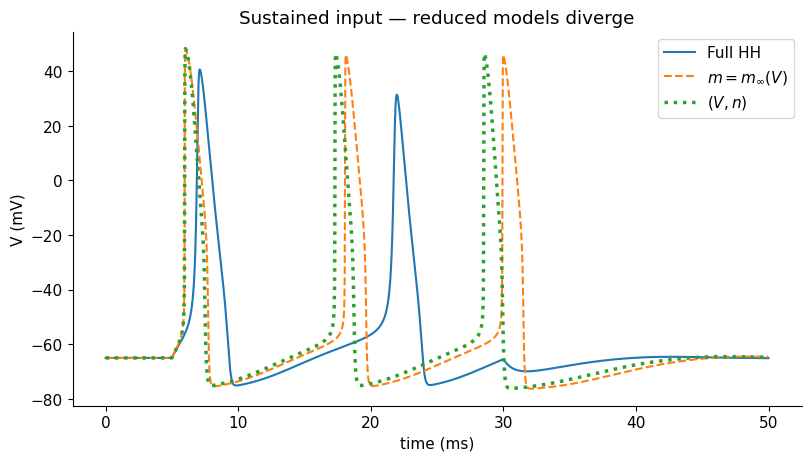

Full HH   : 2 spike(s)
3-state   : 3 spike(s)
2-state   : 3 spike(s)


In [ ]:
TEST_AMP = 10.0
TEST_START, TEST_END = 5.0, 30.0

full_long  = M.simulate_hh(I_amp=TEST_AMP, t_start=TEST_START, t_end=TEST_END)
three_long = M.simulate_hh_three_variable(I_amp=TEST_AMP, t_start=TEST_START, t_end=TEST_END)
two_long   = M.simulate_hh_two_variable(I_amp=TEST_AMP, t_start=TEST_START, t_end=TEST_END,
                                         a_fit=a_fit, b_fit=b_fit)

plt.figure()
plt.plot(full_long["t"],  full_long["V"],  label="Full HH")
plt.plot(three_long["t"], three_long["V"], "--", label=r"$m=m_\infty(V)$")
plt.plot(two_long["t"],   two_long["V"],   ":", lw=2.5, label=r"$(V,n)$")
plt.xlabel("time (ms)"); plt.ylabel("V (mV)")
plt.title("Sustained input — reduced models diverge"); plt.legend()
plt.show()

for name, res in [("Full HH", full_long), ("3-state", three_long), ("2-state", two_long)]:
    sp = M.detect_spikes(res["t"], res["V"], EVENT_THRESHOLD)
    print(f"{name:10s}: {len(sp)} spike(s)")

## 4. From events to a network that learns

The discrete event is the **input unit** for the network scale. The chain:

$$
\text{spike } t_j^{(k)} \;\longrightarrow\; \text{synaptic trace } r_j(t)
\;\longrightarrow\; \textstyle\sum_j w_{ij}\,r_j \;\longrightarrow\; \text{new spike}
$$

Each neuron is a **leaky integrate-and-fire (LIF)** unit:

$$
\tau_m\frac{dV_i}{dt} = -(V_i - E_L) + R_m \sum_j w_{ij}\,r_j(t),
\quad V_i \ge V_\theta \Rightarrow \text{spike},\; V_i \leftarrow V_{\text{reset}}.
$$

### 4.1 Events become continuous synaptic currents

A spike increments a trace that decays exponentially: $r_j \leftarrow r_j + 1$ at
each spike; $\tau_s\,dr_j/dt = -r_j$ between spikes. Multiple spikes
**temporally summate**; different neurons **spatially summate** via weights.

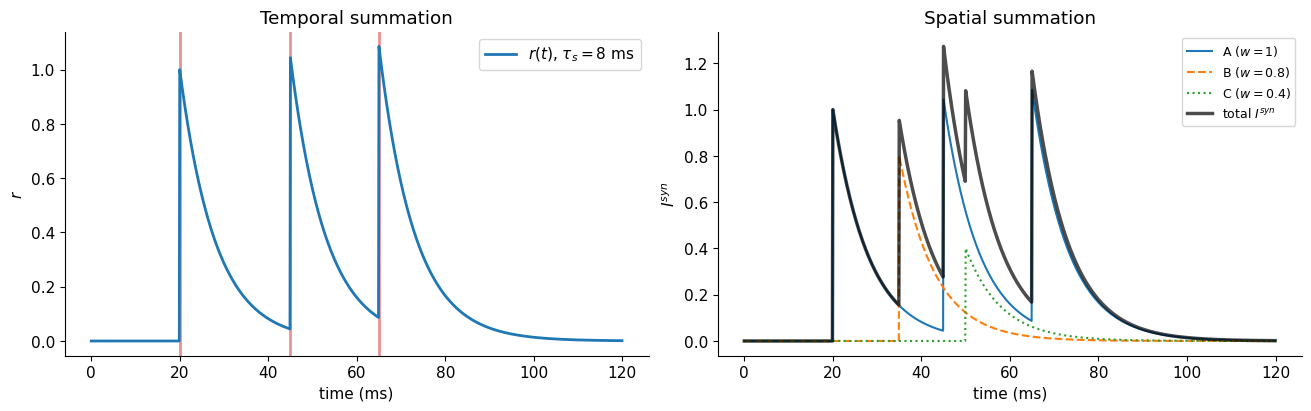

In [ ]:
spike_times_a = np.array([20., 45., 65.])
t_a, r_a = M.synaptic_trace(spike_times_a, tau_s=8.0, duration=120.)
spike_times_b = np.array([35.])
t_b, r_b = M.synaptic_trace(spike_times_b, tau_s=8.0, duration=120., weight=0.8)
spike_times_c = np.array([50.])
t_c, r_c = M.synaptic_trace(spike_times_c, tau_s=8.0, duration=120., weight=0.4)

fig, axs = plt.subplots(1, 2, figsize=(13, 4))
for ts in spike_times_a:
    axs[0].axvline(ts, color="C3", lw=2, alpha=0.5)
axs[0].plot(t_a, r_a, color="C0", lw=2, label=r"$r(t)$, $\tau_s=8$ ms")
axs[0].set_title("Temporal summation"); axs[0].set_xlabel("time (ms)")
axs[0].set_ylabel(r"$r$"); axs[0].legend()

axs[1].plot(t_a, r_a, color="C0", lw=1.5, label=r"A ($w=1$)")
axs[1].plot(t_b, r_b, color="C1", lw=1.5, ls="--", label=r"B ($w=0.8$)")
axs[1].plot(t_c, r_c, color="C2", lw=1.5, ls=":", label=r"C ($w=0.4$)")
axs[1].plot(t_a, r_a + r_b + r_c, color="k", lw=2.5, alpha=0.7, label=r"total $I^{syn}$")
axs[1].set_title("Spatial summation"); axs[1].set_xlabel("time (ms)")
axs[1].set_ylabel(r"$I^{syn}$"); axs[1].legend(fontsize=9)
plt.show()

---

> **Extension — Short-term plasticity (Tsodyks–Markram)**  
> *Not covered in the one-hour lecture. Explore at home.*


The exponential synaptic kernel above assumes a **static** synapse: every spike
releases the same amount. Real synapses can change transmission efficiency
moment-to-moment — they **tire** (depression) or **warm up** (facilitation) —
without changing the long-term weight $w_{ij}$.

The Tsodyks–Markram model adds a resource pool $x$ and utilization $u$:

$$
\text{spike:}\; x \leftarrow x(1-u),\; u \leftarrow u + U(1-u).
\quad
\text{between:}\; \dot{x} = (1-x)/\tau_{\text{rec}},\; \dot{u} = -(u-U)/\tau_{\text{facil}}.
$$

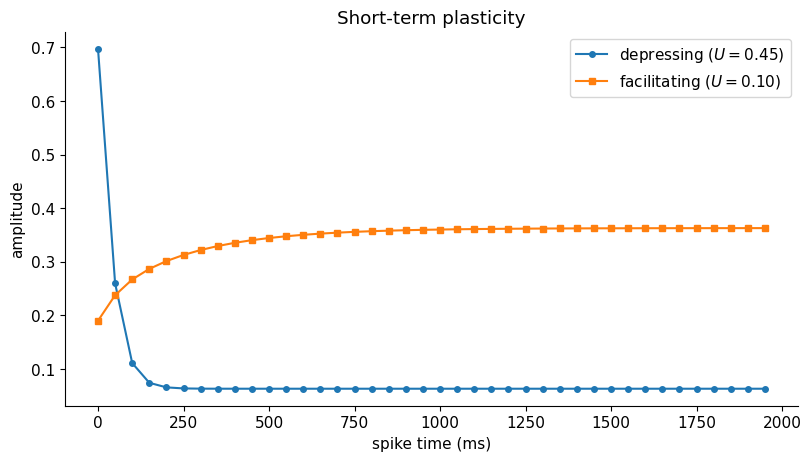

In [ ]:
spikes = np.arange(0, 2000, 50.0)
dep = M.tsodyks_markram_response(spikes, U=0.45, tau_rec=750.0, tau_facil=50.0)
fac = M.tsodyks_markram_response(spikes, U=0.10, tau_rec=80.0,  tau_facil=600.0)
plt.figure()
plt.plot(spikes, dep, "o-", ms=4, label="depressing ($U=0.45$)")
plt.plot(spikes, fac, "s-", ms=4, label="facilitating ($U=0.10$)")
plt.xlabel("spike time (ms)"); plt.ylabel("amplitude")
plt.title("Short-term plasticity"); plt.legend()
plt.show()

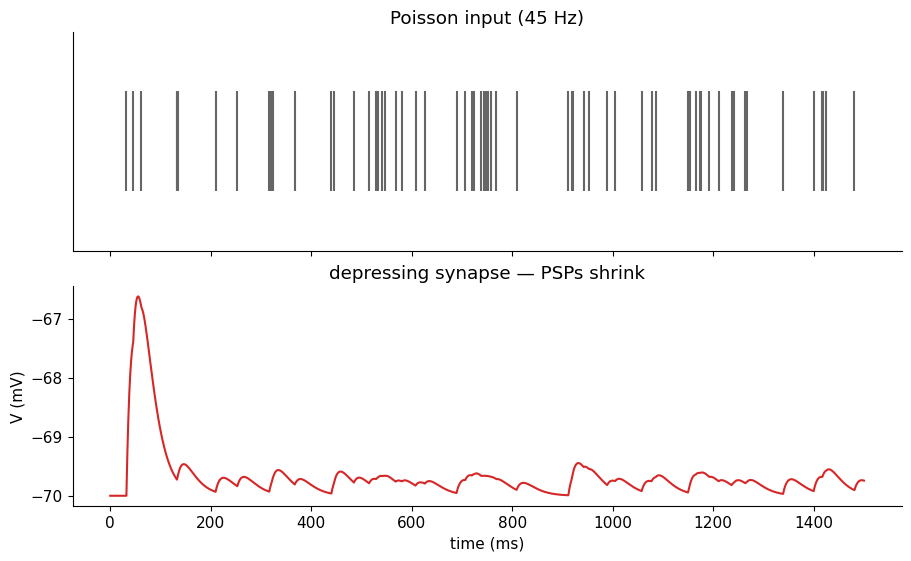

In [ ]:
tt, vv, inspk = M.feedforward_demo(rate=45.0, seed=1)
fig, axs = plt.subplots(2, 1, figsize=(9, 5.5), sharex=True)
axs[0].eventplot(inspk, colors="0.4", lineoffsets=0.5); axs[0].set_yticks([])
axs[0].set_title("Poisson input (45 Hz)")
axs[1].plot(tt, vv, color="C3")
axs[1].set_ylabel("V (mV)"); axs[1].set_xlabel("time (ms)")
axs[1].set_title("depressing synapse — PSPs shrink")
plt.show()

### 4.2 STDP — learning by spike timing

Weights are not fixed. **Spike-timing-dependent plasticity (STDP)** rewrites
$w_{ij}$ based on relative timing:

$$
\Delta w_{ij} =
\begin{cases}
+A_{+}\,e^{-\Delta t/\tau_{+}}, & \text{pre before post (strengthen)}\\
-A_{-}\,e^{\Delta t/\tau_{-}},  & \text{pre after post (weaken)}
\end{cases}
$$

**"Neurons that fire together, wire together."** Repeated co-firing builds a
**cell assembly** — the memory lives in the wiring.

### 4.3 Learning & recall — pattern completion

**64 neurons on an 8×8 grid** (one neuron = one pixel).

**Learn:** repeatedly co-activate pattern pixels → STDP strengthens within-assembly
weights. **Recall:** show a partial cue → do recurrent weights recruit the rest?

*Train the network (a few seconds), then view the learned weight matrix and the
target shape.*

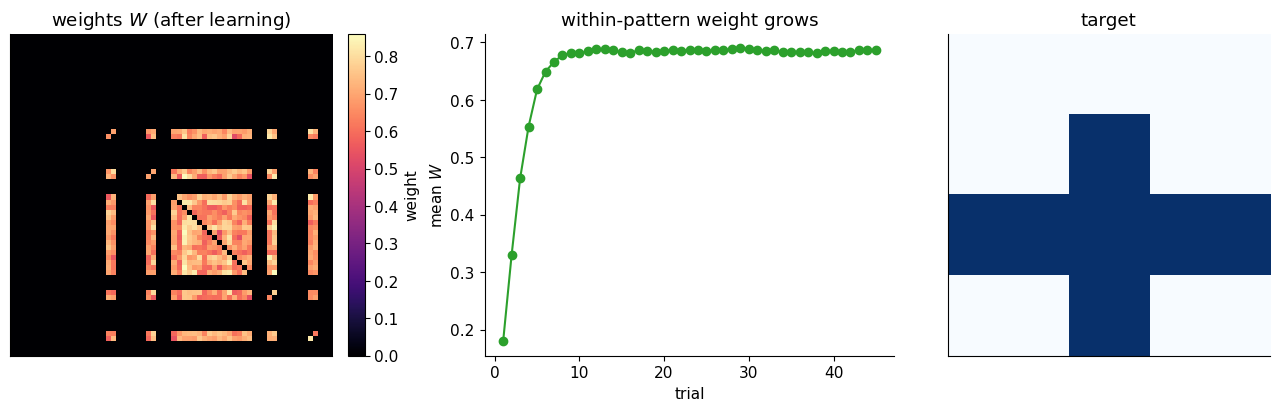

In [3]:
SHAPE = "plus"
N_TRIALS = 45

pattern = M.shape_pixels(SHAPE)
net, whist = M.train_network(pattern, n_trials=N_TRIALS, seed=0)

fig, axs = plt.subplots(1, 3, figsize=(14, 4))
im0 = axs[0].imshow(net.w, vmin=0, vmax=net.w.max(), cmap="magma")
axs[0].set_title("weights $W$ (after learning)")
fig.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04, label="weight")
axs[1].plot(np.arange(1, len(whist)+1), whist, "o-", color="C2")
axs[1].set_title("within-pattern weight grows"); axs[1].set_xlabel("trial")
axs[1].set_ylabel("mean $W$")
target = np.zeros(64); target[pattern] = 1.0
axs[2].imshow(target.reshape(8, 8), cmap="Blues"); axs[2].set_title("target")
axs[2].set_xticks([]); axs[2].set_yticks([])
axs[0].set_xticks([]); axs[0].set_yticks([])
plt.show()

*Recall before vs after learning — same half-cue. Without learning, only cue
pixels fire. After learning, recurrent weights recruit the missing pixels:
**pattern completion**.*

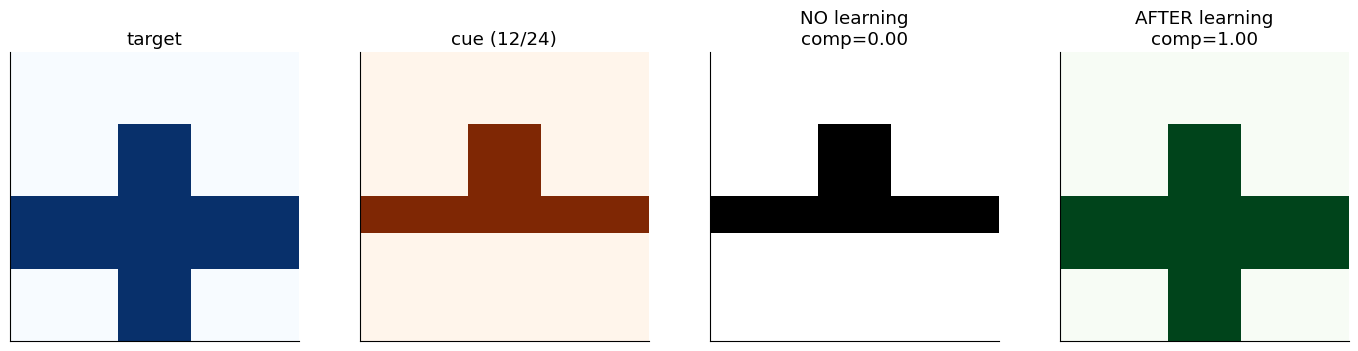

In [ ]:
cue = pattern[: pattern.size // 2]
net_before, _ = M.train_network(pattern, n_trials=0, seed=0)
r_before = M.probe_recall(net_before, pattern, cue)
r_after  = M.probe_recall(net, pattern, cue)

cue_img = np.zeros(64); cue_img[cue] = 1.0
fb = M.recall_activity_map(r_before)
fa = M.recall_activity_map(r_after)

fig, axs = plt.subplots(1, 4, figsize=(14, 3.4))
axs[0].imshow(target.reshape(8, 8), cmap="Blues", vmin=0, vmax=1); axs[0].set_title("target")
axs[1].imshow(cue_img.reshape(8, 8), cmap="Oranges", vmin=0, vmax=1)
axs[1].set_title(f"cue ({cue.size}/{pattern.size})")
axs[2].imshow(fb.reshape(8, 8), cmap="Greys", vmin=0, vmax=1)
axs[2].set_title(f"NO learning\ncomp={r_before['completeness']:.2f}")
axs[3].imshow(fa.reshape(8, 8), cmap="Greens", vmin=0, vmax=1)
axs[3].set_title(f"AFTER learning\ncomp={r_after['completeness']:.2f}")
for a in axs: a.set_xticks([]); a.set_yticks([])
plt.show()

### 4.4 The stability boundary

As noise rises, **false-positive rate** (non-pattern neurons firing) increases.
The gap between completeness (blue) and false-positive rate (red) is the zone
of reliable recall — the assembly's **attractor basin**.

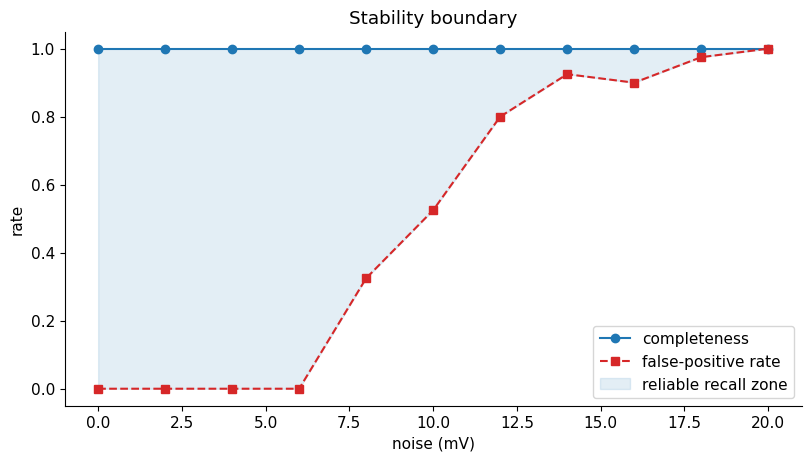

In [ ]:
net_s, wh, pat = M.get_trained("plus")
rng = np.random.default_rng(7)
c_half = pat[: pat.size//2]
noise_levels = np.linspace(0, 20, 11)
comp_noise, fp_noise = [], []
for nv in noise_levels:
    net_s.p.noise = float(nv)
    r = M.probe_recall(net_s, pat, c_half, background_all=12.0)
    comp_noise.append(r["completeness"])
    fp_noise.append(r["false_positive_rate"])
net_s.p.noise = 3.0

plt.figure()
plt.plot(noise_levels, comp_noise, "o-", color="C0", label="completeness")
plt.plot(noise_levels, fp_noise, "s--", color="C3", label="false-positive rate")
plt.fill_between(noise_levels, comp_noise, fp_noise, alpha=0.12, color="C0",
                  label="reliable recall zone")
plt.xlabel("noise (mV)"); plt.ylabel("rate"); plt.ylim(-0.05, 1.05)
plt.title("Stability boundary"); plt.legend()
plt.show()

---

> **Extension — Interactive recall — stress-test the memory**  
> *Not covered in the one-hour lecture. Explore at home.*


The stability curve above swept noise systematically. Now explore interactively:
vary cue size and noise with sliders. The recall panel shows all neurons that
fired; the title reports both completeness and false-positive rate.

- How little cue can you show and still recover the whole shape?
- At what noise level do false positives flood the grid?

In [ ]:
interact(M.explore_recall, shape_name=["plus", "ring", "H", "T"],
         cue_keep=(0.2, 1.0, 0.05), noise=(0.0, 20.0, 1.0));

interactive(children=(Dropdown(description='shape_name', options=('plus', 'ring', 'H', 'T'), value='plus'), Fl…

---

> **Extension — Recall animation**  
> *Not covered in the one-hour lecture. Explore at home.*


Watch the assembly ignite frame by frame (10 ms per frame). The faint gray
background shows the target shape; green pixels are neurons that fired in that
time bin.

In [ ]:
from IPython.display import HTML
ani = M.animate_image_recall("plus", cue_keep=0.5, noise=3.0)
HTML(ani.to_jshtml())

## 5. Take-home

*The figure below summarises the entire pipeline in one view — from the HH spike
through discrete events and STDP to pattern completion.*

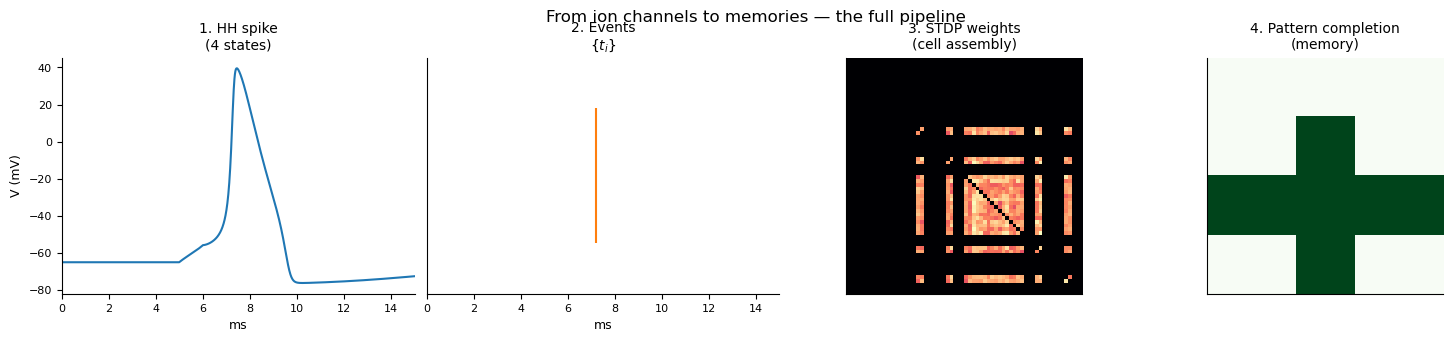

In [ ]:
fig, axs = plt.subplots(1, 4, figsize=(15, 3.2))

# Panel 1: HH spike
hh = M.simulate_hh(I_amp=10.0, t_start=5.0, t_end=6.0)
axs[0].plot(hh["t"], hh["V"], color="C0", lw=1.5)
axs[0].set_xlim(0, 15); axs[0].set_title("1. HH spike\n(4 states)", fontsize=10)
axs[0].set_ylabel("V (mV)", fontsize=9); axs[0].set_xlabel("ms", fontsize=9)
axs[0].tick_params(labelsize=8)

# Panel 2: discrete events
sp = M.detect_spikes(hh["t"], hh["V"], 0.0)
axs[1].eventplot([sp], lineoffsets=[0.5], linelengths=0.8, colors=["C1"])
axs[1].set_xlim(0, 15); axs[1].set_ylim(-0.2, 1.2)
axs[1].set_yticks([]); axs[1].set_title("2. Events\n$\\{t_i\\}$", fontsize=10)
axs[1].set_xlabel("ms", fontsize=9); axs[1].tick_params(labelsize=8)

# Panel 3: learned weight matrix
pat = M.shape_pixels("plus")
net_trained, _ = M.train_network(pat, n_trials=45, seed=0)
axs[2].imshow(net_trained.w, cmap="magma")
axs[2].set_title("3. STDP weights\n(cell assembly)", fontsize=10)
axs[2].set_xticks([]); axs[2].set_yticks([])

# Panel 4: pattern completion
cue = pat[:pat.size//2]
r_after = M.probe_recall(net_trained, pat, cue)
fa = M.recall_activity_map(r_after)
axs[3].imshow(fa.reshape(8, 8), cmap="Greens", vmin=0, vmax=1)
axs[3].set_title("4. Pattern completion\n(memory)", fontsize=10)
axs[3].set_xticks([]); axs[3].set_yticks([])

fig.suptitle("From ion channels to memories — the full pipeline", fontsize=12, y=1.02)
plt.show()

1. **Reduction is disciplined.** $m$ removed by timescale; $h$ by correlation;
   waveform $\to$ events because the network only needs timing.

2. **Events are the universal currency.** Ion channels $\to$ continuous voltage
   $\to$ discrete events $\to$ continuous synaptic current $\to$ new events.

3. **Memory = self-organized wiring.** STDP builds a cell assembly from
   co-firing; the assembly completes partial input. **The wiring is the memory.**

4. **Different scales, different questions.** Single cell: *which channels?*
   Network: *which neurons fire together?*

---

> **Extension — Hopfield network vs. our spiking STDP model**  
> *Not covered in the one-hour lecture. Explore at home.*


Both are **attractor networks**: give a partial cue, and the dynamics converge
to a stored pattern. But they differ in almost every implementation detail:

| | **Hopfield** | **Our model** |
|---|---|---|
| **Unit** | binary ($\pm 1$) | spiking LIF |
| **Weights** | offline: $w_{ij}=\sum_\mu \xi_i^\mu\xi_j^\mu$ | online STDP |
| **Symmetry** | required ($w_{ij}=w_{ji}$) | asymmetric allowed |
| **Energy** | $E=-\frac{1}{2}\sum w_{ij}x_ix_j$ | no explicit energy |
| **Dynamics** | deterministic flip | stochastic LIF + noise |
| **Biology** | abstract | spikes, delays, local learning |

> **Discuss:** Which difference matters most for a biological brain? Can you
> think of a question where the Hopfield model would give a misleading answer
> that our spiking model gets right?

## 6. Open questions

1. **Capacity.** How many different pictures can one network store before the
   assemblies start interfering? (Try learning two shapes in the same network.)
2. **Catastrophic forgetting.** If you learn shape B *after* shape A, does A
   survive? How might the brain avoid this?
3. **Which STDP rule?** Our rule is pair-based. Real synapses have triplet
   rules, voltage-dependent rules, homeostasis. What changes?
4. **STP + LTP together.** What if the *same* synapse carried both short-term
   and long-term plasticity? Would it help or hurt recall?
5. **From pixels to concepts.** Our "memory" is an 8$\times$8 bitmap. What
   would it take to store a *category* (e.g. "all cats") rather than one fixed
   pattern?

> *Every one is a slider or a one-line change away. Try them!*

---

*Engine: `tutorial_models.py`.  Full version: `Multiscale_Modelling_Tutorial.ipynb`.*